In [101]:
import os
import sys
import shutil
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt

from IPython.display    import display, HTML
from datetime           import date
from sklearn.model_selection    import train_test_split
from methods.Modeling   import Catboost_classificator
from methods.Estimators import (
                                    matrix, 
                                    get_metrics, 
                                    clear_only_files,
                                    BinaryClassificationEvaluator, 
                                    find_best_threshold,
                                    sampling_test,
                                    perform_rfecv,
                                    intervals,
                                    find_feature_importance_catboost,
                                    error_matrix,
                                    total_stata,
                                    mean_absolute_percentage_error,
                                    calculate_columnwise_mape,
                                    save_importances,
                                    plot_roc_lift,
                                    plot_tpr_tnr_intersection,
                                    find_best_threshold_prev,
                                    plot_optimal_proba
                                )

from sklearn.metrics   import (
                                precision_recall_curve,
                                accuracy_score,
                                recall_score,
                                precision_score,
                                roc_auc_score,
                                f1_score
                                
                            )


In [102]:
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
display(HTML("<style>.container { width:99% !important; }</style>"))
pd.options.display.float_format = '{:,.3f}'.format
pd.set_option('display.max_columns', None)
# ширина каждого столбца (в символах)
pd.set_option('display.max_colwidth', None)

# Фиксируем ВСЕ случайные seed
np.random.seed(0)
import random
random.seed(0)

In [103]:
path = f'prepared_data/data_for_modeling.pickle'
# загрузка данных
with open(path, 'rb') as f:
    samples = pickle.load(f)

# проверим, какие ключи есть в загруженном словаре
print("Ключи в samples:", samples.keys())

Ключи в samples: dict_keys(['train', 'valid', 'test', 'test_time', 'target', 'reasons_df', 'info_fields', 'features', 'cat_features', 'features_intervals'])


In [104]:
train        = samples['train']
valid        = samples['valid']
test         = samples['test']
test_time    = samples['test_time']
info         = samples['info_fields']
features     = sorted(samples['features'])
cat_features = samples['cat_features']
target       = samples['target']
reasons_df   = samples['reasons_df']
features_intervals = samples['features_intervals']
build = pd.concat([train, valid])

# Разбиваем на подвыборки

In [105]:
print('======= Распределение таргетов: =======')

print('train:')
print(train[target].value_counts(normalize=True))
print('valid:')
print(valid[target].value_counts(normalize=True))
print('test:')
print(test[target].value_counts(normalize=True))
print('test_time:')
print(test_time[target].value_counts(normalize=True))
print('build:')
print(build[target].value_counts(normalize=True))

======= Распределение таргетов: =======
train:
target
0   0.513
1   0.487
Name: proportion, dtype: float64
valid:
target
0   0.513
1   0.487
Name: proportion, dtype: float64
test:
target
0   0.513
1   0.487
Name: proportion, dtype: float64
test_time:
target
0   0.535
1   0.465
Name: proportion, dtype: float64
build:
target
0   0.513
1   0.487
Name: proportion, dtype: float64


In [106]:
print('======= Размер выборок: =======')

print('train:')
print(train.shape)
print('valid:')
print(valid.shape)
print('test:')
print(test.shape)
print('test_time:')
print(test_time.shape)
print('build:')
print(build.shape)

======= Размер выборок: =======
train:
(86901, 33)
valid:
(21726, 33)
test:
(27157, 33)
test_time:
(2924, 33)
build:
(108627, 33)


In [107]:
X_train, y_train = train[features], train[target]
X_valid, y_valid = valid[features], valid[target]
X_test, y_test   = test[features], test[target]
X_test_time, y_test_time = test_time[features], test_time[target]

# Моделирование

In [108]:
params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': 0.01,
    'depth': 7,
    'l2_leaf_reg': 2,
    # 'od_type': 'Iter',
    # 'od_wait': 200,
    'iterations': 2000,  # Больше итераций
    'auto_class_weights': 'Balanced',
    # 'bootstrap_type': 'Bernoulli',
    # 'subsample': 0.9,
    # 'border_count': 128,  # Увеличиваем количество биннинга
    # 'grow_policy': 'SymmetricTree',  # Для более стабильных вероятностей
    # 'score_function': 'L2',  # Для лучшей калибровки
    # 'min_data_in_leaf': 50,  # Минимум данных в листе
#     'posterior_sampling': True,  # Включает байесовскую калибровку
}
# params = {
#     'auto_class_weights': 'Balanced',
#     'loss_function': 'Logloss',
#     'early_stopping_rounds': 100,
#     'eval_metric': 'AUC',
#     'learning_rate':0.05,
#
# }

In [109]:
# объект класса Катбуст
clf_object = Catboost_classificator()
model = clf_object.catboost_base_model_func(X_train[features], y_train, 
                                            X_valid[features], y_valid, 
                                            cat_features , 
                                            params)

0:	test: 0.5401276	best: 0.5401276 (0)	total: 20ms	remaining: 40s
50:	test: 0.5621011	best: 0.5621011 (50)	total: 1.48s	remaining: 56.4s
100:	test: 0.5705546	best: 0.5705546 (100)	total: 2.27s	remaining: 42.8s
150:	test: 0.5754260	best: 0.5754835 (149)	total: 3.06s	remaining: 37.4s
200:	test: 0.5787494	best: 0.5787826 (194)	total: 3.86s	remaining: 34.5s
250:	test: 0.5815792	best: 0.5816137 (249)	total: 4.67s	remaining: 32.6s
300:	test: 0.5843134	best: 0.5843134 (300)	total: 5.51s	remaining: 31.1s
350:	test: 0.5866832	best: 0.5867074 (349)	total: 6.33s	remaining: 29.8s
400:	test: 0.5892021	best: 0.5892558 (399)	total: 7.14s	remaining: 28.5s
450:	test: 0.5911475	best: 0.5911475 (450)	total: 7.96s	remaining: 27.4s
500:	test: 0.5928229	best: 0.5928229 (500)	total: 8.78s	remaining: 26.3s
550:	test: 0.5950551	best: 0.5950880 (549)	total: 9.61s	remaining: 25.3s
600:	test: 0.5963547	best: 0.5963757 (598)	total: 10.4s	remaining: 24.2s
650:	test: 0.5969401	best: 0.5970027 (648)	total: 11.2s	rema

In [126]:
# ==== Сохранение модели в pickle ====
model.save_model('models/catboost_model.cbm')

print(f"Модель сохранена: {model_path}")

Модель сохранена: models/catboost_model.pickle


## importances

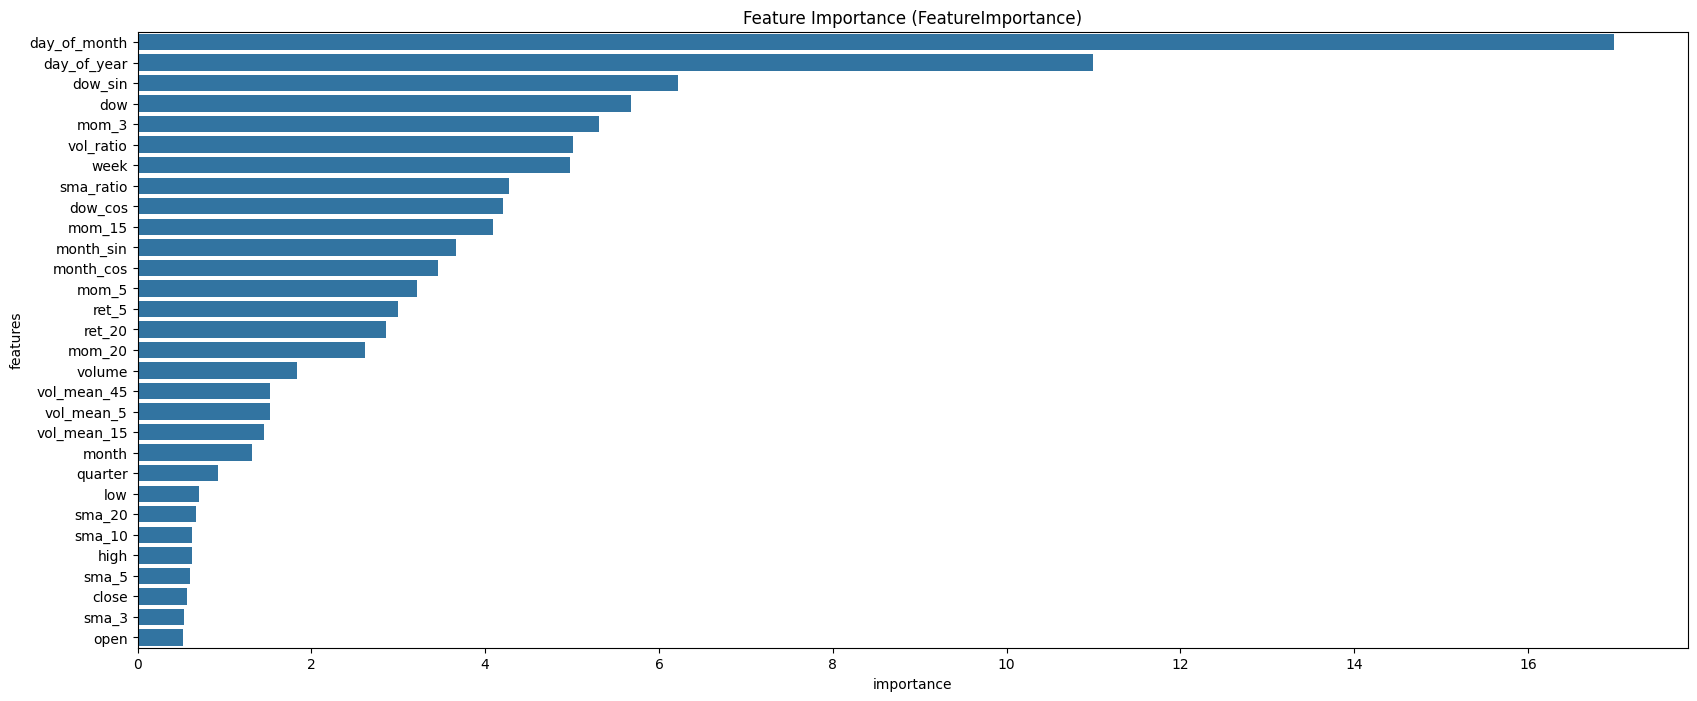

In [110]:
features_importances  = find_feature_importance_catboost(X_train[features], y_train, cat_features, model, 'FeatureImportance', '', False)

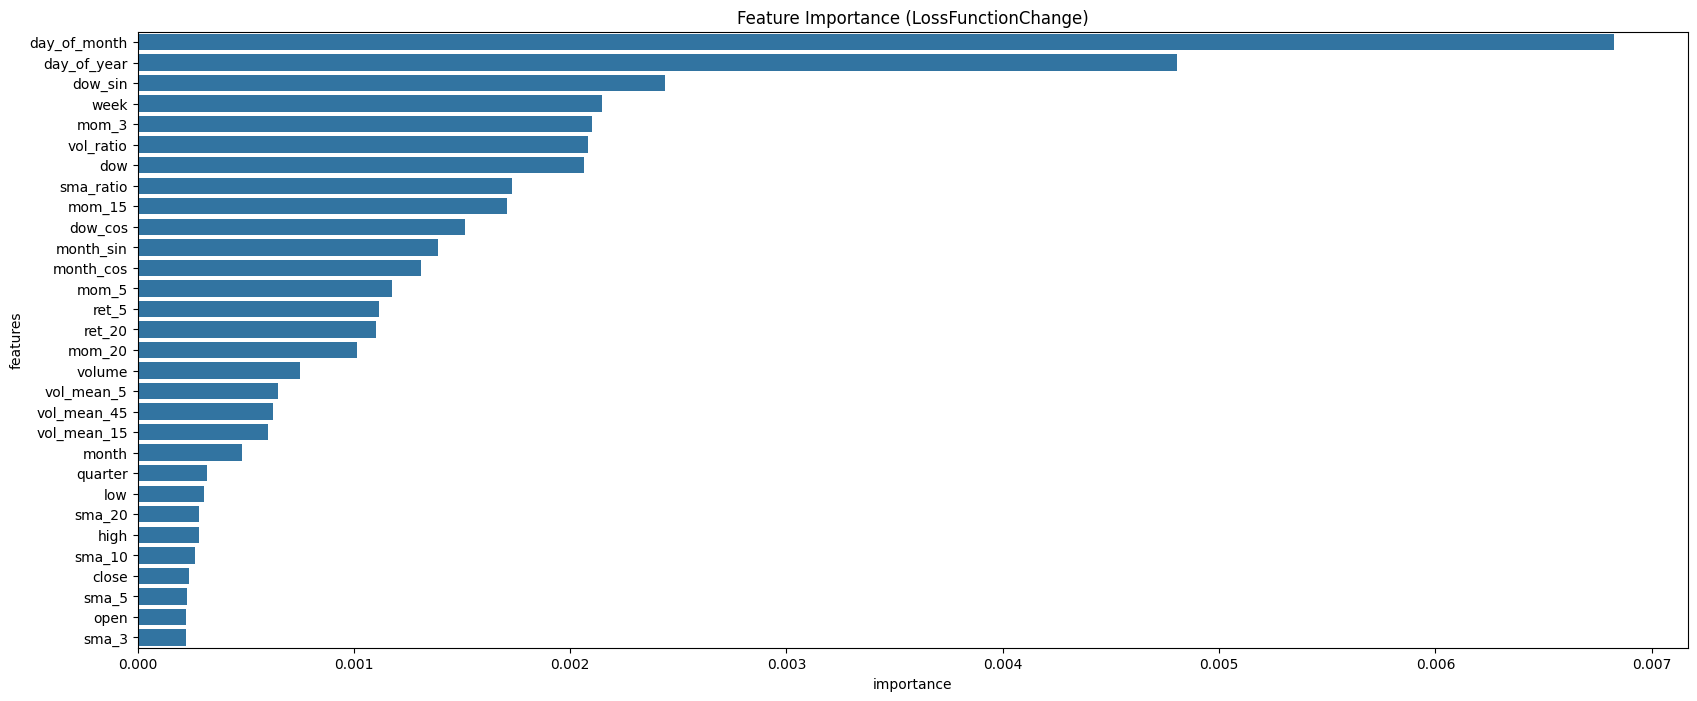

In [111]:
loss_importances      = find_feature_importance_catboost(X_train[features], y_train, cat_features, model, 'LossFunctionChange', '', False)

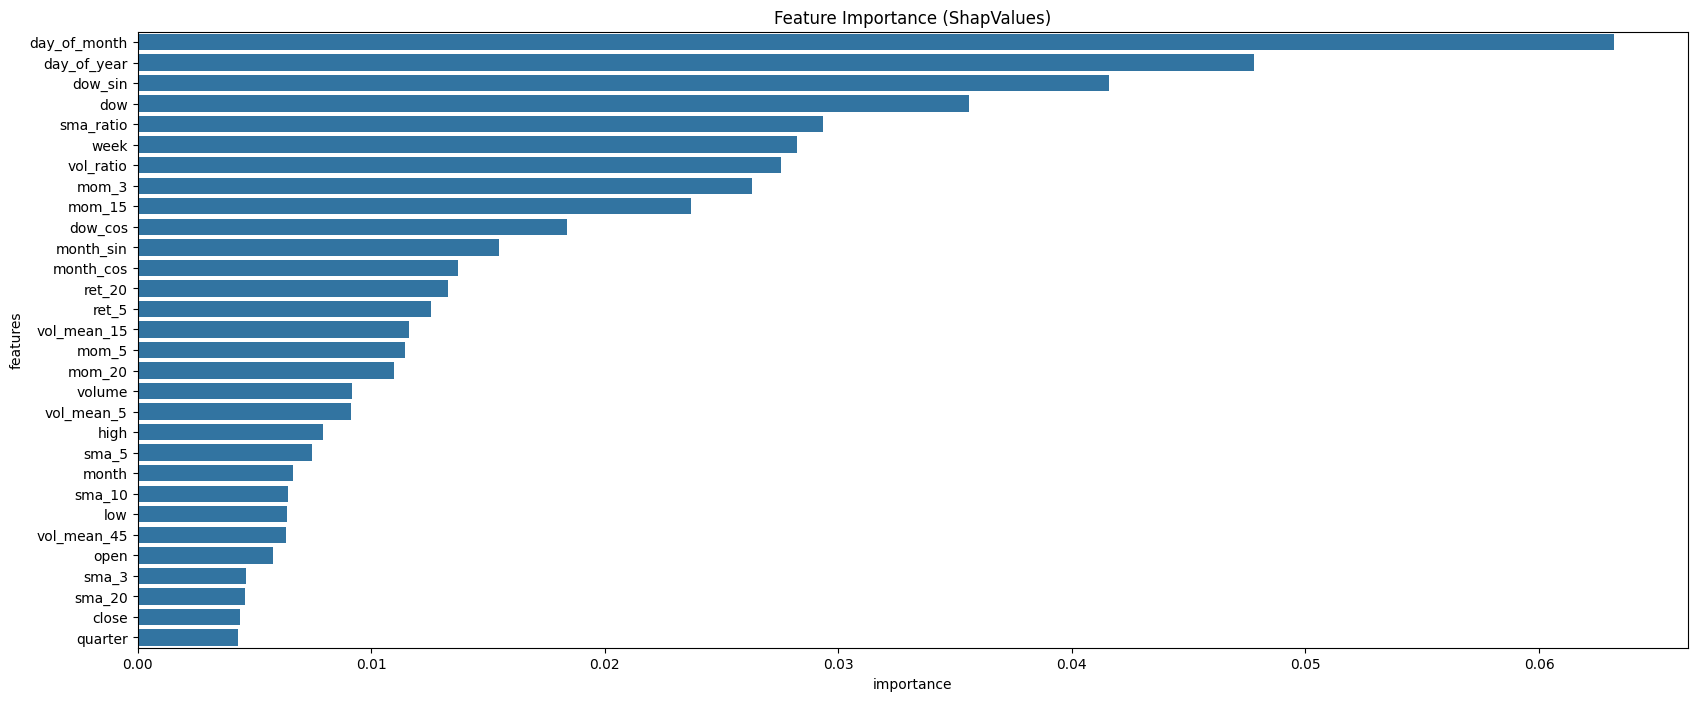

In [112]:
sharp_importances     = find_feature_importance_catboost(X_train[features], y_train, cat_features, model, 'ShapValues', '', False)

# Оптимальный трешхолд по F1

--------Оптимальный трешхолд по FPR/TPR--------
threshold - 0.49, на модели model


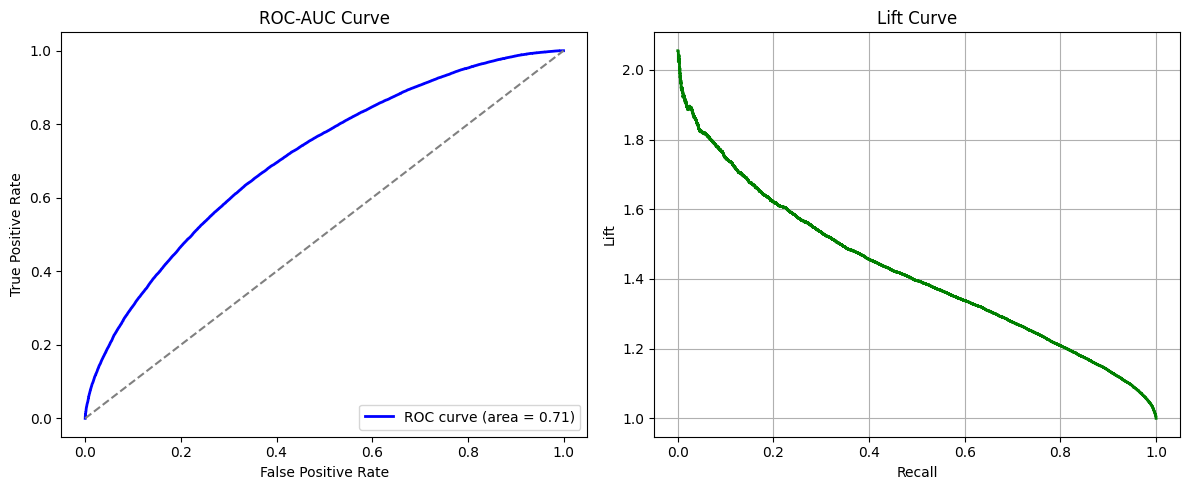

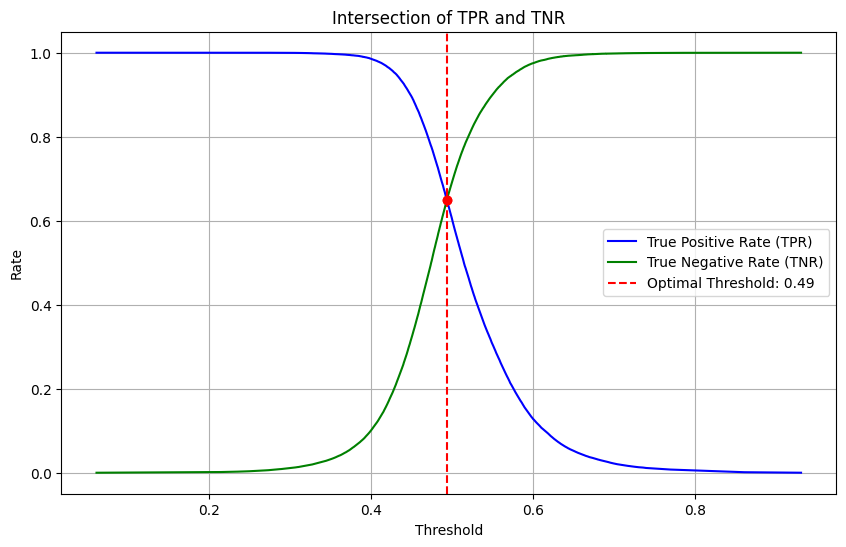

Optimal Threshold: 0.49
TPR at Optimal Threshold: 0.65
TNR at Optimal Threshold: 0.65


In [113]:
print('--------Оптимальный трешхолд по FPR/TPR--------')

build_pred_proba = model.predict_proba(build[model.feature_names_])[:, 1]
threshold, optimal_tpr, optimal_tnr, thresholds, fpr, tpr, tnr = find_best_threshold(y_true = build[target], y_pred_proba = build_pred_proba)
threshold  = round(threshold, 2)
build_pred = (build_pred_proba >= threshold).astype(int)
print(f'threshold - {threshold}, на модели model')

# графики с трешхолдами / verbose = FALSE - чтобы графики не сохранялись, просто посмотреть на них
plot_roc_lift(y_true = build[target], y_pred_proba = build_pred_proba, path = '', verbose= False)
plot_tpr_tnr_intersection(y_true = build[target], y_pred_proba = build_pred_proba, path = '', verbose= False)

In [127]:
with open('models/threshold.json', 'w') as f:
    json.dump(threshold, f)

------------- Графики ------------- 


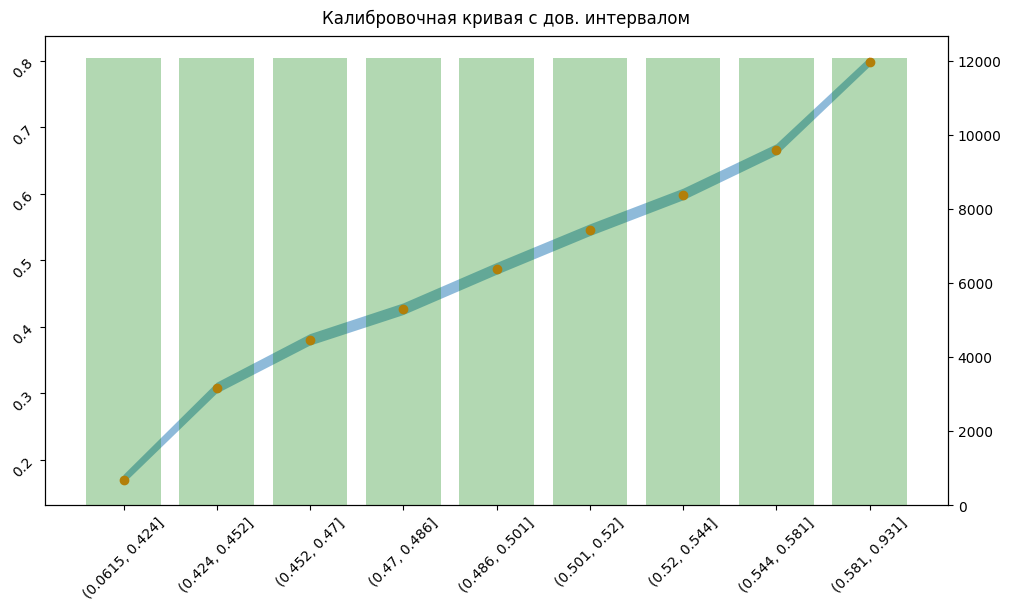

None

In [114]:
print('------------- Графики ------------- ')
metrics_graphs = BinaryClassificationEvaluator(build[target], build_pred, build_pred_proba)
display(metrics_graphs.plot_calibration(path = '', verbose =False))

# Test Sample

In [115]:
print('------------- Метрики ------------- ')
y_pred_prob = model.predict_proba(X_test[features])[:, 1]  # Predict probabilities for the positive class
y_pred = (y_pred_prob >= threshold).astype(int) #

methods_dict = {
    'binary': 'Считает метрику только для положительного класса (обычно метка 1). Дефолтный метод', 
    'micro': 'Считает общую метрику на уровне всех экземпляров. Суммирует все True Positives (TP), False Positives (FP), False Negatives (FN) по всем классам, затем считает метрику по этим суммам.', 
    'macro': 'Считает метрику по каждому классу отдельно, а затем усредняет без учета дисбаланса классов (все классы равновесны)', 
    'weighted': 'Считает метрику как macro, но учитывает долю каждого класса (вес по количеству примеров).'
}

metrics_dict = {
    'Accuracy': round(accuracy_score(y_test, y_pred), 3),
    'ROC-AUC': round(roc_auc_score(y_test, y_pred_prob), 3), 
}

for metric_methods, desription in methods_dict.items():
    metrics_dict[metric_methods] = {
        'Метрики': {
            'Precision': round(precision_score(y_test, y_pred, average = metric_methods), 3),
            "Recall"   : round(recall_score(y_test, y_pred, average = metric_methods), 3),
            "F1"       : round(f1_score(y_test, y_pred, average = metric_methods), 3)
        },
        'Описание': desription
}

display(metrics_dict)


------------- Метрики ------------- 


{'Accuracy': 0.591,
 'ROC-AUC': 0.628,
 'binary': {'Метрики': {'Precision': 0.574, 'Recall': 0.619, 'F1': 0.595},
  'Описание': 'Считает метрику только для положительного класса (обычно метка 1). Дефолтный метод'},
 'micro': {'Метрики': {'Precision': 0.591, 'Recall': 0.591, 'F1': 0.591},
  'Описание': 'Считает общую метрику на уровне всех экземпляров. Суммирует все True Positives (TP), False Positives (FP), False Negatives (FN) по всем классам, затем считает метрику по этим суммам.'},
 'macro': {'Метрики': {'Precision': 0.592, 'Recall': 0.592, 'F1': 0.591},
  'Описание': 'Считает метрику по каждому классу отдельно, а затем усредняет без учета дисбаланса классов (все классы равновесны)'},
 'weighted': {'Метрики': {'Precision': 0.592, 'Recall': 0.591, 'F1': 0.591},
  'Описание': 'Считает метрику как macro, но учитывает долю каждого класса (вес по количеству примеров).'}}

МАТРИЦА ОШИБОК
ROC-AUC: 0.6283825933090896


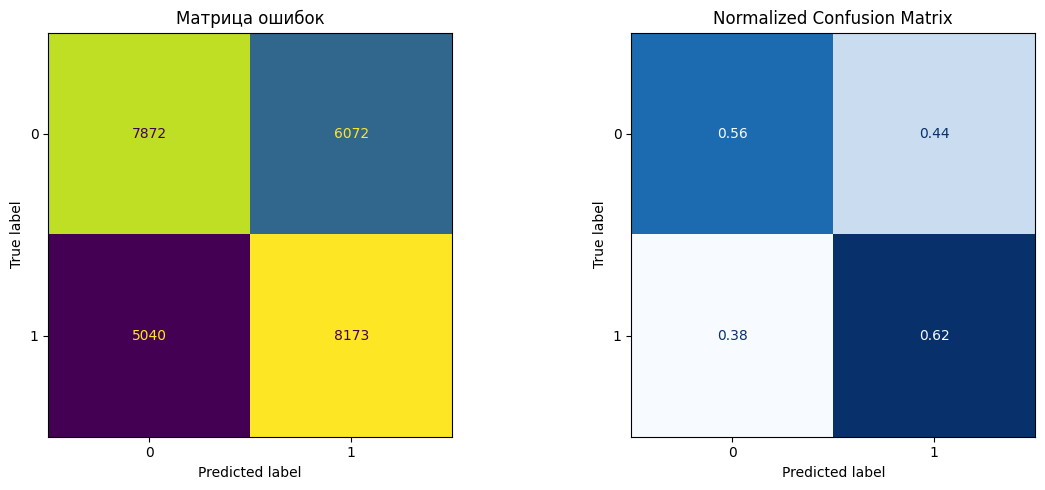

In [116]:
print('МАТРИЦА ОШИБОК')

error_matrix(X_test[features], y_test, model,threshold)

------------- Графики ------------- 


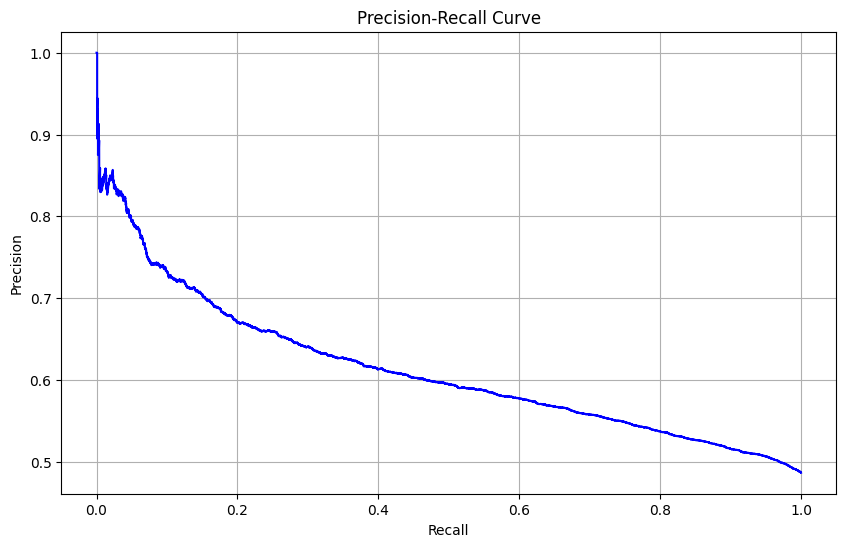

None

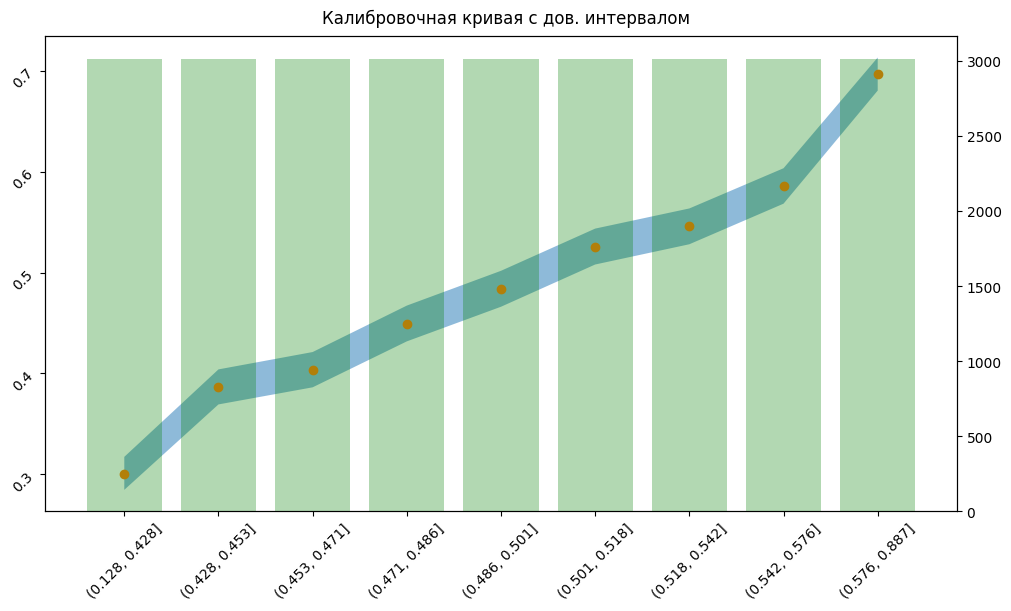

None

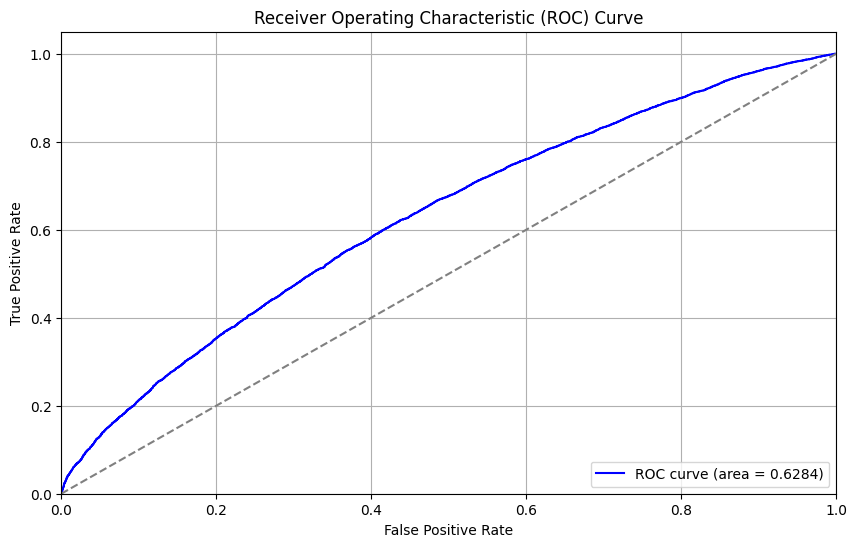

None

In [117]:
print('------------- Графики ------------- ')
metrics_graphs = BinaryClassificationEvaluator(y_test, y_pred, y_pred_prob)
display(metrics_graphs.plot_precision_recall_curve(path = '', verbose =False))
display(metrics_graphs.plot_calibration(path = '', verbose =False))
display(metrics_graphs.plot_roc_curve(path = '', verbose =False))

# Test Time

In [118]:
print('------------- Метрики ------------- ')
y_pred_prob = model.predict_proba(X_test_time[features])[:, 1]  # Predict probabilities for the positive class
y_pred = (y_pred_prob >= threshold).astype(int) #

methods_dict = {
    'binary': 'Считает метрику только для положительного класса (обычно метка 1). Дефолтный метод',
    'micro': 'Считает общую метрику на уровне всех экземпляров. Суммирует все True Positives (TP), False Positives (FP), False Negatives (FN) по всем классам, затем считает метрику по этим суммам.',
    'macro': 'Считает метрику по каждому классу отдельно, а затем усредняет без учета дисбаланса классов (все классы равновесны)',
    'weighted': 'Считает метрику как macro, но учитывает долю каждого класса (вес по количеству примеров).'
}

metrics_dict = {
    'Accuracy': round(accuracy_score(y_test_time, y_pred), 3),
    'ROC-AUC': round(roc_auc_score(y_test_time, y_pred_prob), 3),
}

for metric_methods, desription in methods_dict.items():
    metrics_dict[metric_methods] = {
        'Метрики': {
            'Precision': round(precision_score(y_test_time, y_pred, average = metric_methods), 3),
            "Recall"   : round(recall_score(y_test_time, y_pred, average = metric_methods), 3),
            "F1"       : round(f1_score(y_test_time, y_pred, average = metric_methods), 3)
        },
        'Описание': desription
}

display(metrics_dict)


------------- Метрики ------------- 


{'Accuracy': 0.525,
 'ROC-AUC': 0.529,
 'binary': {'Метрики': {'Precision': 0.493, 'Recall': 0.711, 'F1': 0.582},
  'Описание': 'Считает метрику только для положительного класса (обычно метка 1). Дефолтный метод'},
 'micro': {'Метрики': {'Precision': 0.525, 'Recall': 0.525, 'F1': 0.525},
  'Описание': 'Считает общую метрику на уровне всех экземпляров. Суммирует все True Positives (TP), False Positives (FP), False Negatives (FN) по всем классам, затем считает метрику по этим суммам.'},
 'macro': {'Метрики': {'Precision': 0.542, 'Recall': 0.537, 'F1': 0.516},
  'Описание': 'Считает метрику по каждому классу отдельно, а затем усредняет без учета дисбаланса классов (все классы равновесны)'},
 'weighted': {'Метрики': {'Precision': 0.545, 'Recall': 0.525, 'F1': 0.511},
  'Описание': 'Считает метрику как macro, но учитывает долю каждого класса (вес по количеству примеров).'}}

МАТРИЦА ОШИБОК
ROC-AUC: 0.5294279967074753


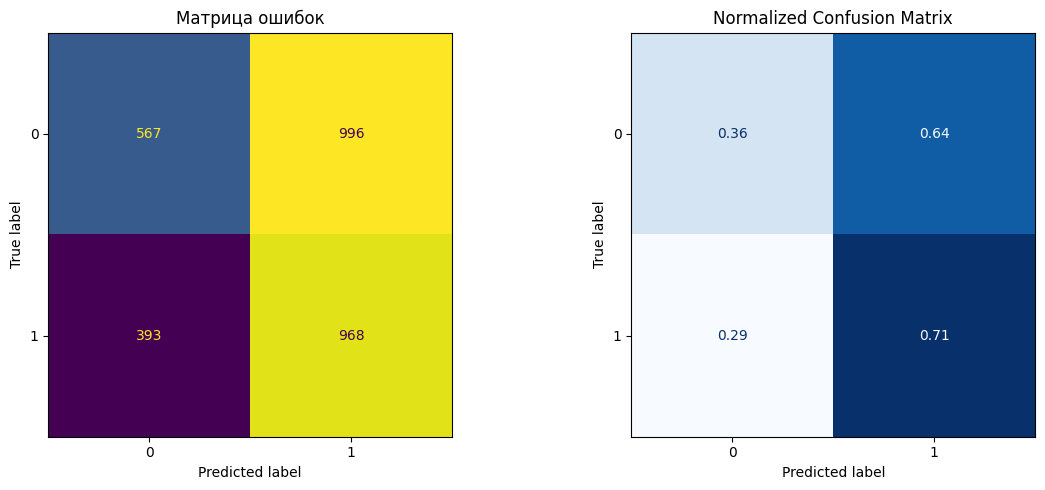

In [119]:
print('МАТРИЦА ОШИБОК')

error_matrix(X_test_time[features], y_test_time, model,threshold)

------------- Графики ------------- 


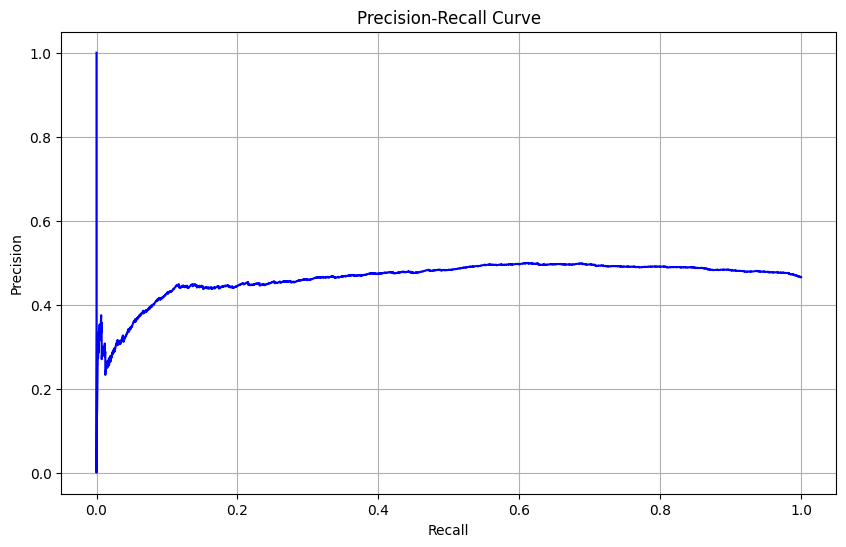

None

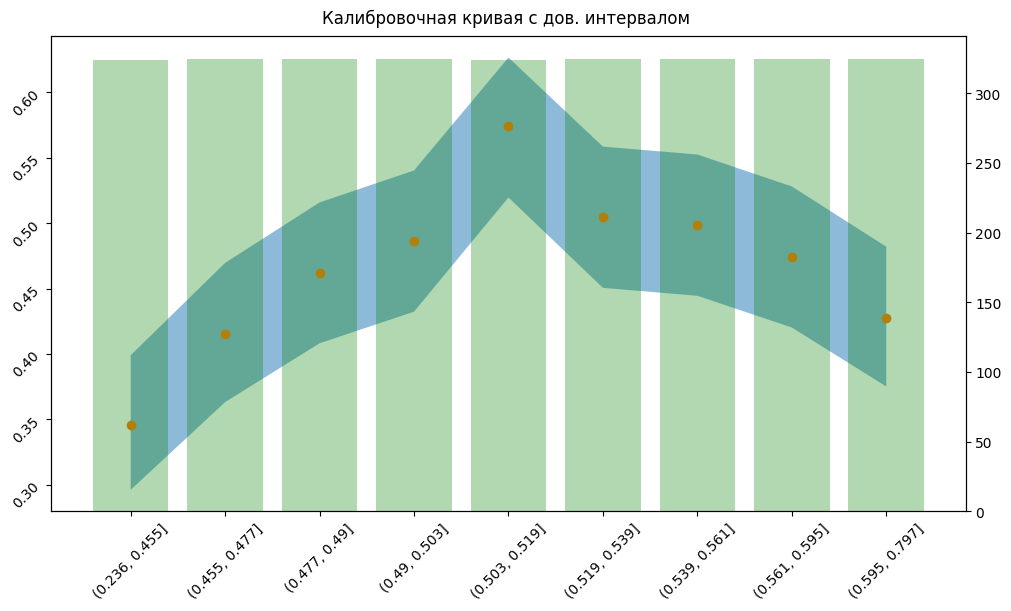

None

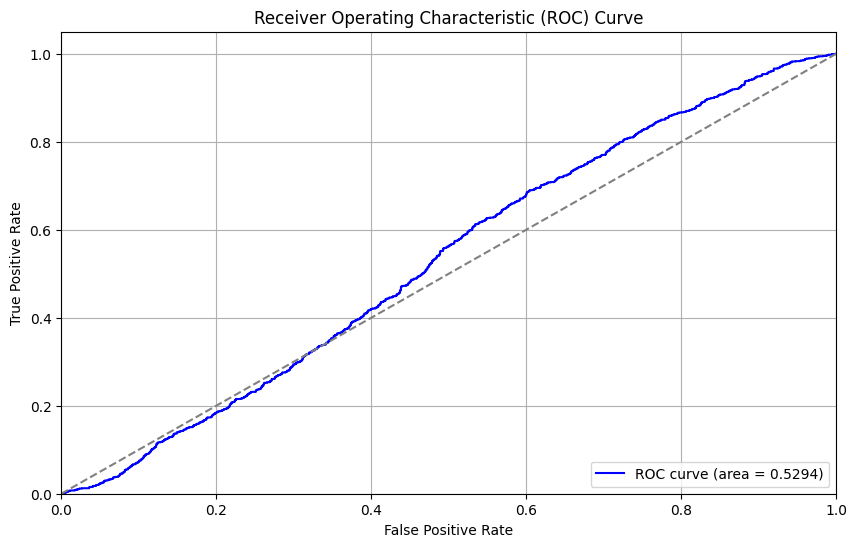

None

In [120]:
print('------------- Графики ------------- ')
metrics_graphs = BinaryClassificationEvaluator(y_test_time, y_pred, y_pred_prob)
display(metrics_graphs.plot_precision_recall_curve(path = '', verbose =False))
display(metrics_graphs.plot_calibration(path = '', verbose =False))
display(metrics_graphs.plot_roc_curve(path = '', verbose =False))